In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df=pd.read_csv("placement.csv")
df.sample(5)

,cgpa,placement_exam_marks,placed
251,6.46,45.0,0
700,6.82,16.0,1
153,6.29,10.0,1
474,7.11,25.0,1
219,5.48,3.0,0


In [4]:
df.shape

(1000, 3)

Text(0.5, 1.0, 'Distribution of Placement Exam Marks')

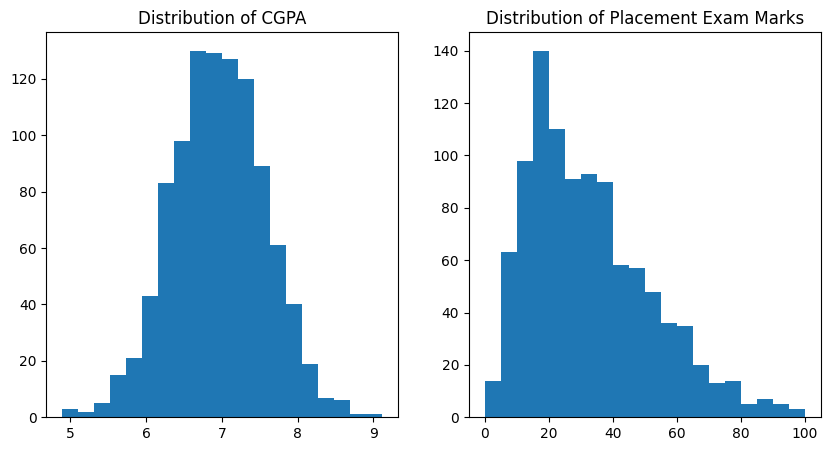

In [11]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.hist(df['cgpa'], bins=20)
plt.title('Distribution of CGPA')


plt.subplot(1,2,2)
plt.hist(df['placement_exam_marks'], bins=20)
plt.title('Distribution of Placement Exam Marks')



In [12]:
# means that is gpa is normally distributed .So we can 
# use z-score method to remove outliers from cgpa column 
print('Mean of CGPA:', df['cgpa'].mean())
print('Standard Deviation of CGPA:', df['cgpa'].std())
print('Minimum of CGPA:', df['cgpa'].min())
print('Maximum of CGPA:', df['cgpa'].max())

Mean of CGPA: 6.96124
Standard Deviation of CGPA: 0.6158978751323896
Minimum of CGPA: 4.89
Maximum of CGPA: 9.12


In [13]:
# finding the boundries values for outliers using z-score method
print('Highest allowed CGPA:', df['cgpa'].mean() + 3*df['cgpa'].std())
print('Lowest allowed CGPA:', df['cgpa'].mean() - 3*df['cgpa'].std())

Highest allowed CGPA: 8.808933625397168
Lowest allowed CGPA: 5.113546374602832


In [14]:
# Finding the outliers in cgpa column
df[(df['cgpa']>8.8) | (df['cgpa']<5.1)]

,cgpa,placement_exam_marks,placed
485,4.92,44.0,1
995,8.87,44.0,1
996,9.12,65.0,1
997,4.89,34.0,0
999,4.90,10.0,1


### Trimming

In [ ]:
new_df=df[(df['cgpa']<=8.8) & (df['cgpa']>=5.1)]
new_df.sample(5)

,cgpa,placement_exam_marks,placed
933,6.01,9.0,0
682,6.34,17.0,1
523,6.13,19.0,0
191,6.63,8.0,0
418,6.30,29.0,0


In [17]:
new_df.shape

(995, 3)

In [18]:
# Approch 02
# calculating z score for each value in cgpa column
df['cgpa_zscore'] = (df['cgpa'] - df['cgpa'].mean()) / df['cgpa'].std()

In [20]:
df.sample(5)

,cgpa,placement_exam_marks,placed,cgpa_zscore
79,7.63,19.0,1,1.085829
883,7.98,6.0,1,1.654105
279,8.49,40.0,1,2.482165
27,6.53,46.0,0,-0.700181
208,7.25,12.0,1,0.468844


In [21]:
df[df['cgpa_zscore']>3]

,cgpa,placement_exam_marks,placed,cgpa_zscore
995,8.87,44.0,1,3.099150
996,9.12,65.0,1,3.505062


In [22]:
df[df['cgpa_zscore']<-3]


,cgpa,placement_exam_marks,placed,cgpa_zscore
485,4.92,44.0,1,-3.314251
997,4.89,34.0,0,-3.362960
999,4.90,10.0,1,-3.346724


In [23]:
df[(df['cgpa_zscore']<=3) & (df['cgpa_zscore']>=-3)]

,cgpa,placement_exam_marks,placed,cgpa_zscore
0,7.19,26.0,1,0.371425
1,7.46,38.0,1,0.809810
2,7.54,40.0,1,0.939701
3,6.42,8.0,1,-0.878782
4,7.23,17.0,0,0.436371
...,...,...,...,...
991,7.04,57.0,0,0.127878
992,6.26,12.0,0,-1.138565
993,6.73,21.0,1,-0.375452
994,6.48,63.0,0,-0.781363


In [27]:
# trimming
new_df=df[(df['cgpa_zscore']<=3) & (df['cgpa_zscore']>=-3)]
new_df

,cgpa,placement_exam_marks,placed,cgpa_zscore
0,7.19,26.0,1,0.371425
1,7.46,38.0,1,0.809810
2,7.54,40.0,1,0.939701
3,6.42,8.0,1,-0.878782
4,7.23,17.0,0,0.436371
...,...,...,...,...
991,7.04,57.0,0,0.127878
992,6.26,12.0,0,-1.138565
993,6.73,21.0,1,-0.375452
994,6.48,63.0,0,-0.781363


### Capping

In [28]:
upper_limit = df['cgpa'].mean() + 3*df['cgpa'].std()
lower_limit = df['cgpa'].mean() - 3*df['cgpa'].std()

In [29]:
lower_limit, upper_limit

(np.float64(5.113546374602832), np.float64(8.808933625397168))

In [30]:
df['cgpa']=np.where(
    df['cgpa']>upper_limit,
    upper_limit,
    np.where(
        df['cgpa']<lower_limit,
        lower_limit,
        df['cgpa']
    )
)

In [31]:
df.shape

(1000, 4)

In [32]:
df['cgpa'].describe()

count    1000.000000
mean        6.961499
std         0.612688
min         5.113546
25%         6.550000
50%         6.960000
75%         7.370000
max         8.808934
Name: cgpa, dtype: float64